In [1]:
import os
from scipy.io import savemat
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mesa.features import stft, stft_labels
from mesa.visualization import plot_signal, dual_plot, spectrogram
import librosa
from airPLS import airPLS
from mesa.fusion import unfold_2D

In [2]:
os.getcwd()

'/home/gsus/Documentos/GitHub/MESA/external/examples/GC-FID'

In [3]:
# Read data
F_data = pd.read_csv("../../../external/data/GC-FID/Y_data.csv", header=None)
F_data_matrix = F_data.to_numpy()

idx = np.where(np.sum(F_data_matrix, axis=1) == 0)
idx_blank_24h = [0, 1, 2, 3]
idx_blank_72h = [52, 53, 54, 55]

df = pd.read_csv("../../../external/data/GC-FID/X_data.csv", header=None)
X = df.to_numpy().T

In [4]:
# STFT calculation
filter_freqs = True
center = False
sr = 200
n_samples = 45001
window_length = n_samples // 200
hop = window_length//2
window_function = "hann"
n_fft = window_length *10

D = stft(X, window_length, hop, window=window_function, center=center, n_fft=n_fft)
Sxx = D
times, freqs = stft_labels(D, sr, hop, n_fft=n_fft)

In [5]:
freqs.shape, times.shape

((1126,), (382,))

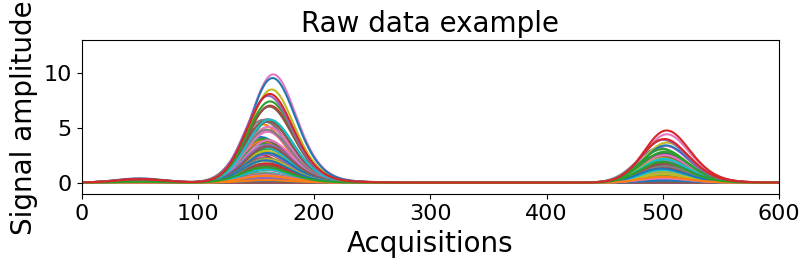

In [9]:
# Raw signal
signal_id = 10
trim = (17400, 18000)
fontsize = 20;
fontsize2 = 16;

fig, ax = plt.subplots(1,1, figsize = (9, 2))
ax.plot(X[:, trim[0]:trim[1]].T/1e4);
plt.xlim(75, 550)
plt.ylim(-1, 13)
plt.ylabel("Signal amplitude", fontsize=fontsize)
plt.xlabel("Acquisitions", fontsize=fontsize)
plt.title("Raw data example", fontsize=fontsize)



locs, labels = plt.xticks()
xticks = np.array(np.round(np.linspace(0, 600, len(locs)), 0), dtype=int)
plt.xticks(locs, xticks);

plt.xticks(fontsize=fontsize2);
plt.yticks(fontsize=fontsize2);


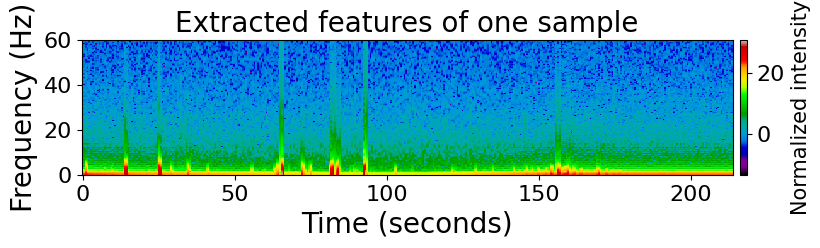

In [11]:
# Spectrogram
signal_id = 10

fontsize = 20;
fontsize2 = 16;


fig, ax = plt.subplots(1,1, figsize = (10, 1.75))
fig, _ = spectrogram(np.log(np.abs(Sxx[signal_id,:,:]**2)+1e-6),
            sr, win_length=window_length, hop=hop, n_fft=n_fft, center=center,
            x_axis='s',
            ax = ax, cmap = "nipy_spectral",
            cb_kwargs={
                'pad': 0.01,
                'label': "Normalized intensity"
            });
plt.ylim(0,60);
plt.title("Extracted features of one sample", fontsize=fontsize)

plt.xlabel("Time (seconds)", fontsize=fontsize)
plt.ylabel("Frequency (Hz)", fontsize=fontsize)

plt.xticks(fontsize=fontsize2);
plt.yticks(fontsize=fontsize2);

for axis in fig.axes:
    if axis.get_label() == '<colorbar>':
        axis.tick_params(labelsize=fontsize2) 
        axis.yaxis.label.set_size(fontsize2-1)



(0.0, 100.0)

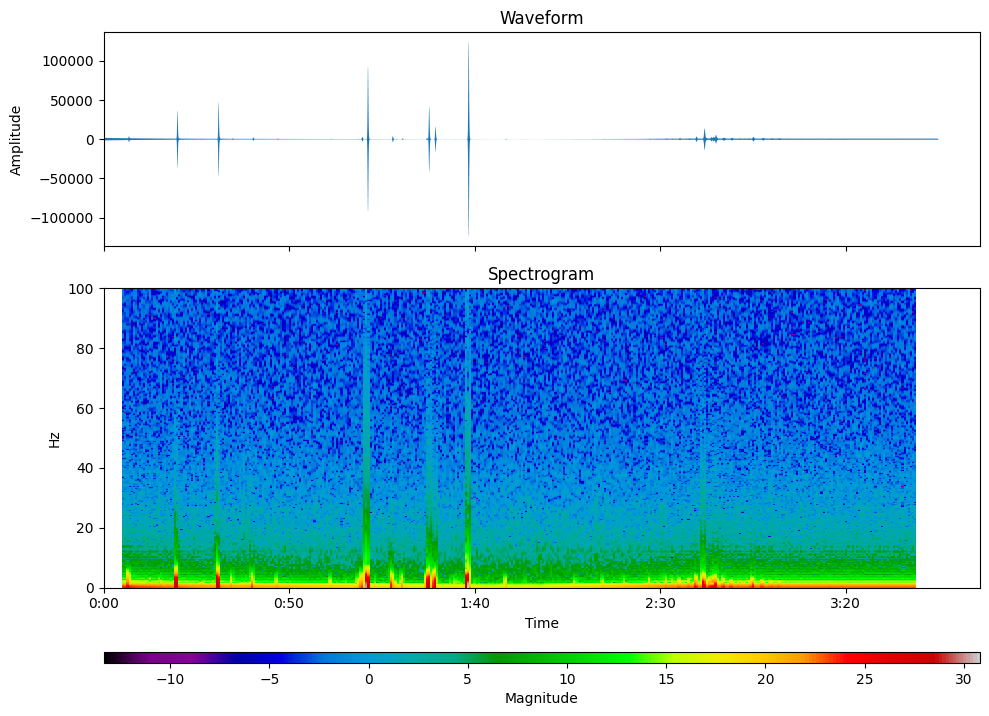

In [8]:
# Dual plot
signal_id = 10
dual_plot(X[signal_id], np.log(np.abs(Sxx[signal_id,:,:]**2)+1e-6),
          sr, win_length=window_length, hop=hop,
          n_fft=n_fft, center=center, cmap="nipy_spectral")
plt.ylim(0, 100)